# Handwritten Digit Clustering (DBSCAN + PCA + KMeans)

This notebook demonstrates how to group similar handwritten digits from the MNIST dataset without using their labels. We will:
1. Load and preprocess the data.
2. Reduce dimensions using Principal Component Analysis (PCA).
3. Apply DBSCAN and KMeans clustering.
4. Visualize and evaluate the resulting clusters.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [2]:

def load_and_preprocess_data(filepath='../data/mnist_train.csv', n_samples=10000, random_state=42):
    """
    Loads the MNIST dataset and preprocesses it.
    
    Args:
        filepath (str): Path to the mnist CSV file.
        n_samples (int): Number of samples to use (for performance reasons with DBSCAN).
                         Set to None to use all data.
        random_state (int): Random seed for reproducibility.
        
    Returns:
        tuple: (scaled_features, true_labels)
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found at {filepath}")
        
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # We assume the first column is 'label' and the rest are pixels
    if 'label' in df.columns:
        labels = df['label']
        features = df.drop('label', axis=1)
    else:
        # Assuming first column is label if not explicitly named
        labels = df.iloc[:, 0]
        features = df.iloc[:, 1:]
        
    if n_samples is not None and n_samples < len(df):
        print(f"Sampling {n_samples} random records out of {len(df)}...")
        df_sample = df.sample(n=n_samples, random_state=random_state)
        if 'label' in df_sample.columns:
            labels = df_sample['label']
            features = df_sample.drop('label', axis=1)
        else:
            labels = df_sample.iloc[:, 0]
            features = df_sample.iloc[:, 1:]
            
    print("Normalizing features...")
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    
    return scaled_features, labels.values



In [3]:

def apply_pca(features, n_components=2):
    """
    Applies PCA to reduce dimensionality of the features.
    
    Args:
        features (numpy.ndarray): The scaled feature matrix.
        n_components (int or float): Number of components to keep, 
                                     or fraction of variance to explain.
                                     
    Returns:
        tuple: (pca_features, pca_model)
    """
    print(f"Applying PCA (n_components={n_components})...")
    pca = PCA(n_components=n_components, random_state=42)
    pca_features = pca.fit_transform(features)
    
    explained_variance = sum(pca.explained_variance_ratio_)
    print(f"Total explained variance by components: {explained_variance:.4f}")
    
    return pca_features, pca



In [4]:

def run_dbscan(features, eps=0.5, min_samples=5):
    """
    Applies DBSCAN clustering to the feature matrix.
    
    Args:
        features (numpy.ndarray): The feature matrix (could be PCA reduced).
        eps (float): The maximum distance between two samples for one to be considered as in the neighborhood of the other.
        min_samples (int): The number of samples in a neighborhood for a point to be considered as a core point.
        
    Returns:
        tuple: (cluster_labels, dbscan_model)
    """
    print(f"Running DBSCAN (eps={eps}, min_samples={min_samples})...")
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(features)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"Estimated number of clusters: {n_clusters}")
    print(f"Estimated number of noise points: {n_noise}")
    
    return labels, dbscan



In [5]:

def run_kmeans(features, n_clusters=10, random_state=42):
    """
    Applies KMeans clustering to the feature matrix.
    
    Args:
        features (numpy.ndarray): The feature matrix (could be PCA reduced).
        n_clusters (int): Number of clusters.
        random_state (int): Random seed.
        
    Returns:
        tuple: (cluster_labels, kmeans_model)
    """
    print(f"Running KMeans (n_clusters={n_clusters})...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    labels = kmeans.fit_predict(features)
    
    return labels, kmeans



In [6]:

def evaluate_clusters(features, cluster_labels, true_labels=None):
    """
    Evaluates clustering performance.
    
    Args:
        features: Feature matrix used for clustering.
        cluster_labels: Predicted labels.
        true_labels: True labels (if available).
        
    Returns:
        dict: Dictionary of metrics.
    """
    metrics = {}
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    metrics['n_clusters'] = n_clusters
    metrics['n_noise'] = n_noise
    
    if n_clusters > 1:
        metrics['silhouette'] = silhouette_score(features, cluster_labels)
    else:
        metrics['silhouette'] = None
        
    if true_labels is not None:
        metrics['ari'] = adjusted_rand_score(true_labels, cluster_labels)
        metrics['nmi'] = normalized_mutual_info_score(true_labels, cluster_labels)
        
    return metrics



In [7]:

def plot_pca_clusters(pca_features, cluster_labels, title="DBSCAN Clustering on PCA-Reduced Data", output_path=None):
    """
    Plots a 2D scatter plot of the PCA features, colored by cluster labels.
    
    Args:
        pca_features (numpy.ndarray): PCA-reduced feature matrix (must have at least 2 dims).
        cluster_labels (numpy.ndarray): Cluster labels from DBSCAN.
        output_path (str, optional): Path to save the plot.
    """
    plt.figure(figsize=(10, 8))
    
    # Identify unique labels
    unique_labels = set(cluster_labels)
    
    # Create a color palette
    palette = sns.color_palette("husl", len(unique_labels))
    
    # Plot noise points (-1) in black
    if -1 in unique_labels:
        mask_noise = (cluster_labels == -1)
        plt.scatter(pca_features[mask_noise, 0], pca_features[mask_noise, 1], 
                    c='black', label='Noise', alpha=0.3, s=10)
    
    # Plot clusters
    for i, label in enumerate(unique_labels):
        if label != -1:
            mask = (cluster_labels == label)
            plt.scatter(pca_features[mask, 0], pca_features[mask, 1], 
                        c=[palette[i]], label=f'Cluster {label}', alpha=0.6, s=15)
            
    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    
    # Only show legend if we don't have too many clusters
    if len(unique_labels) <= 20:
        plt.legend()
        
    plt.tight_layout()
    
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        print(f"Saved cluster plot to {output_path}")
    
    plt.show()

def plot_true_labels(pca_features, true_labels, output_path=None):
    """
    Plots a 2D scatter plot colored by TRUE labels for comparison.
    """
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], 
                    hue=true_labels, palette="tab10", legend="full", alpha=0.6, s=15)
    
    plt.title("PCA-Reduced Data Colored by True Labels")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        print(f"Saved PCA true labels plot to {output_path}")
        
    plt.show()

def plot_pca_variance(pca_model, output_path=None):
    """Plots the explained variance ratio of PCA components."""
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca_model.explained_variance_ratio_), marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.tight_layout()
    
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        print(f"Saved PCA variance plot to {output_path}")
        
    plt.show()

def plot_cluster_comparison(pca_features, labels1, name1, labels2, name2, output_path=None):
    """Plots a side-by-side comparison of two clusterings."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First plot
    unique1 = set(labels1)
    pal1 = sns.color_palette("husl", len(unique1))
    if -1 in unique1:
        mask = (labels1 == -1)
        ax1.scatter(pca_features[mask, 0], pca_features[mask, 1], c='black', label='Noise', alpha=0.3, s=10)
    for i, label in enumerate(unique1):
        if label != -1:
            mask = (labels1 == label)
            ax1.scatter(pca_features[mask, 0], pca_features[mask, 1], c=[pal1[i]], alpha=0.6, s=15)
    ax1.set_title(name1)
    ax1.set_xlabel("Principal Component 1")
    ax1.set_ylabel("Principal Component 2")
    
    # Second plot
    unique2 = set(labels2)
    pal2 = sns.color_palette("husl", len(unique2))
    if -1 in unique2:
        mask = (labels2 == -1)
        ax2.scatter(pca_features[mask, 0], pca_features[mask, 1], c='black', label='Noise', alpha=0.3, s=10)
    for i, label in enumerate(unique2):
        if label != -1:
            mask = (labels2 == label)
            ax2.scatter(pca_features[mask, 0], pca_features[mask, 1], c=[pal2[i]], alpha=0.6, s=15)
    ax2.set_title(name2)
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")
    
    plt.tight_layout()
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        print(f"Saved cluster comparison plot to {output_path}")
    plt.show()



## 1. Data Loading and Preprocessing
We use a subset of the `mnist_train.csv` data to keep the clustering computation reasonable.

In [8]:
# Using 10,000 samples for faster DBSCAN execution
scaled_features, true_labels = load_and_preprocess_data(filepath='../data/mnist_train.csv', n_samples=10000)

Loading data from ../data/mnist_train.csv...


Sampling 10000 random records out of 60000...
Normalizing features...


## 2. Dimensionality Reduction with PCA
MNIST images are 28x28 = 784 dimensions. DBSCAN suffers from the "curse of dimensionality", so we use PCA to reduce the feature space. First, let's reduce it to 50 components for clustering, which retains significant variance.

In [9]:
# Reduce to 50 components for clustering
pca_50_features, pca_50_model = apply_pca(scaled_features, n_components=50)

Applying PCA (n_components=50)...


Total explained variance by components: 0.5866


For 2D visualization, we'll also compute a 2-component PCA.

In [10]:
# Reduce to 2 components for 2D plotting
pca_2_features, pca_2_model = apply_pca(scaled_features, n_components=2)

Applying PCA (n_components=2)...


Total explained variance by components: 0.1015


Saved PCA variance plot to ../outputs/pca_variance.png


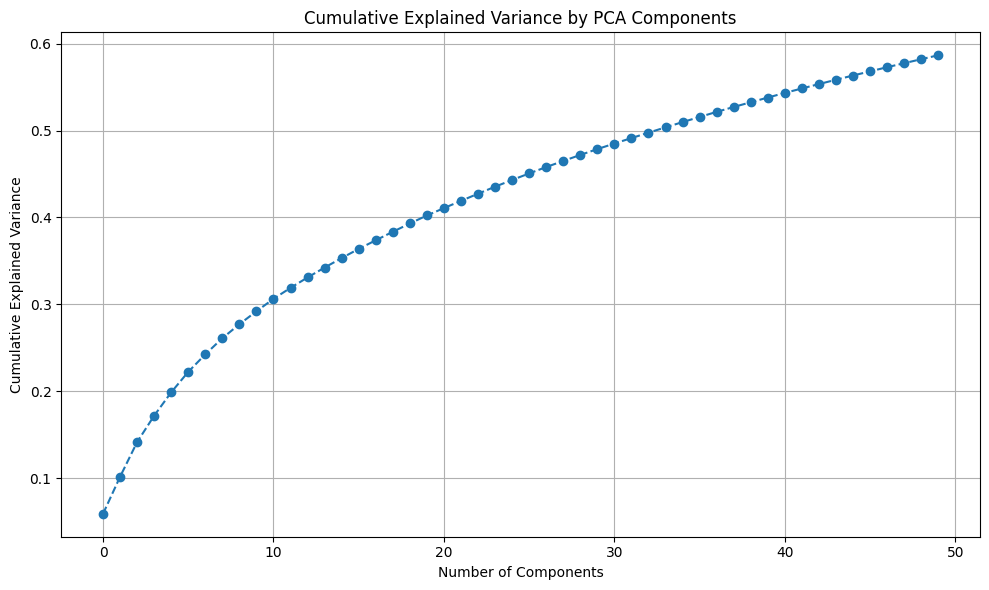

In [11]:
# Plot PCA variance
plot_pca_variance(pca_50_model, output_path='../outputs/pca_variance.png')

Saved PCA true labels plot to ../outputs/true_labels.png


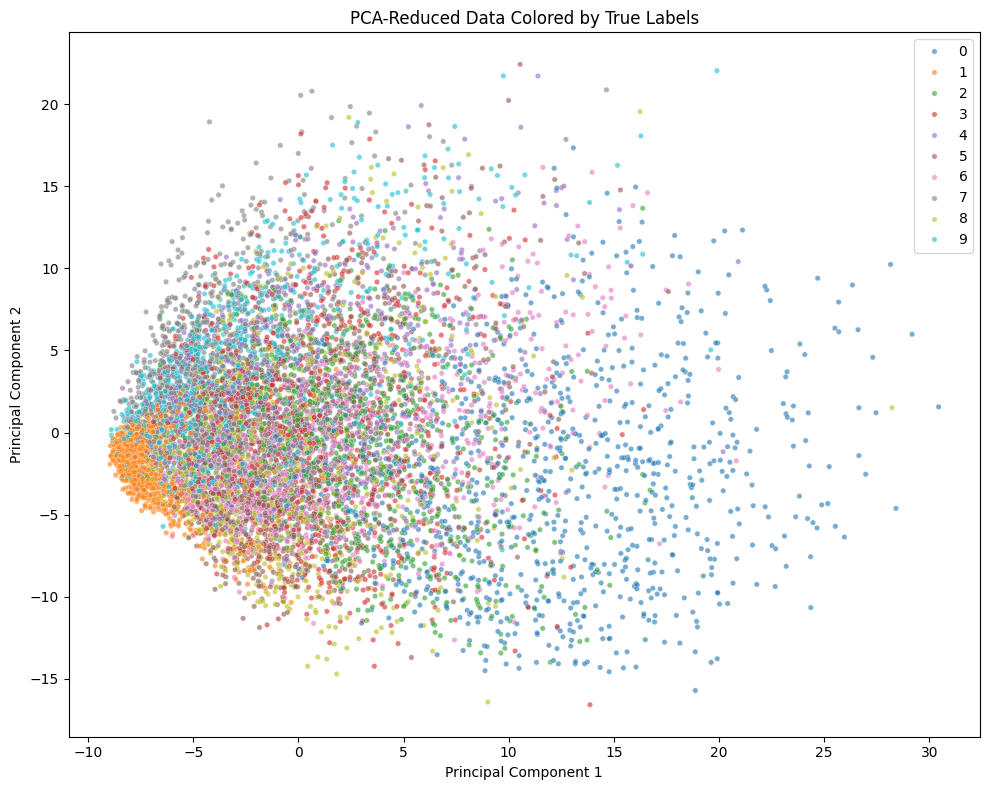

In [12]:
# Plot the data with true labels for a baseline reference
plot_true_labels(pca_2_features, true_labels, output_path='../outputs/true_labels.png')

## 3. Clustering Models
We apply both DBSCAN and KMeans to the 50-dimensional PCA features.

Running DBSCAN (eps=15.0, min_samples=10)...


Estimated number of clusters: 1
Estimated number of noise points: 820


Saved cluster plot to ../outputs/dbscan_clusters.png


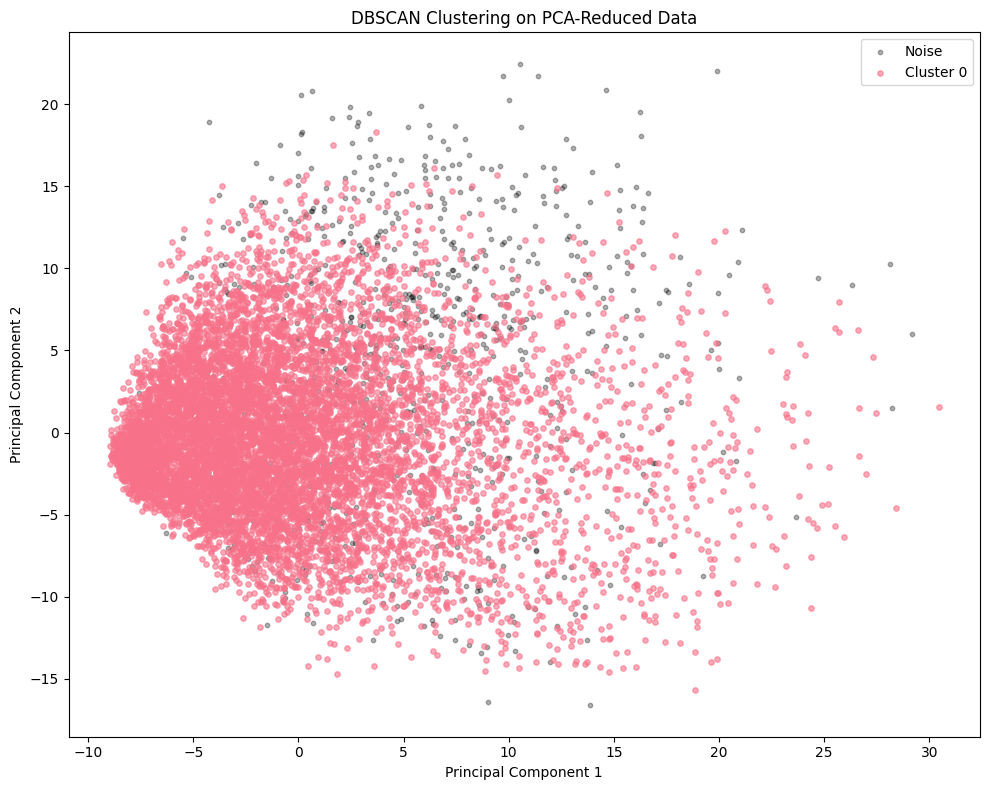

In [13]:
# Run DBSCAN
dbscan_labels, dbscan_model = run_dbscan(pca_50_features, eps=15.0, min_samples=10)
plot_pca_clusters(pca_2_features, dbscan_labels, output_path='../outputs/dbscan_clusters.png')

Running KMeans (n_clusters=10)...


Saved cluster plot to ../outputs/kmeans_clusters.png


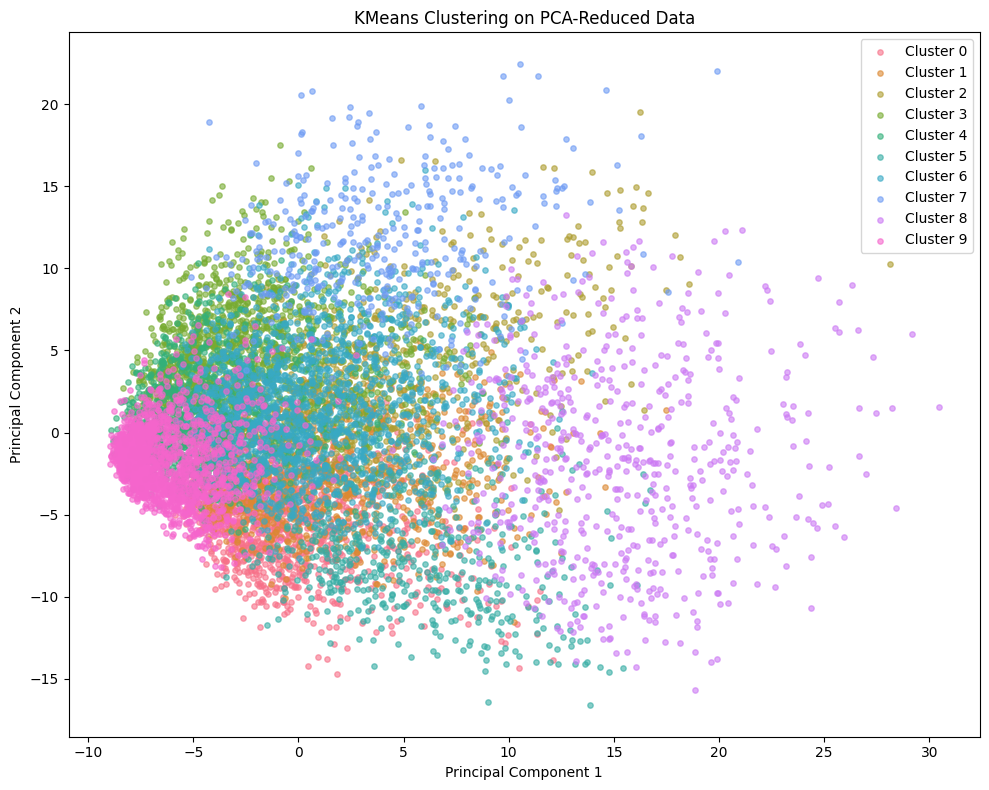

In [14]:
# Run KMeans
kmeans_labels, kmeans_model = run_kmeans(pca_50_features, n_clusters=10)
plot_pca_clusters(pca_2_features, kmeans_labels, title='KMeans Clustering on PCA-Reduced Data', output_path='../outputs/kmeans_clusters.png')


Saved cluster comparison plot to ../outputs/cluster_comparison.png


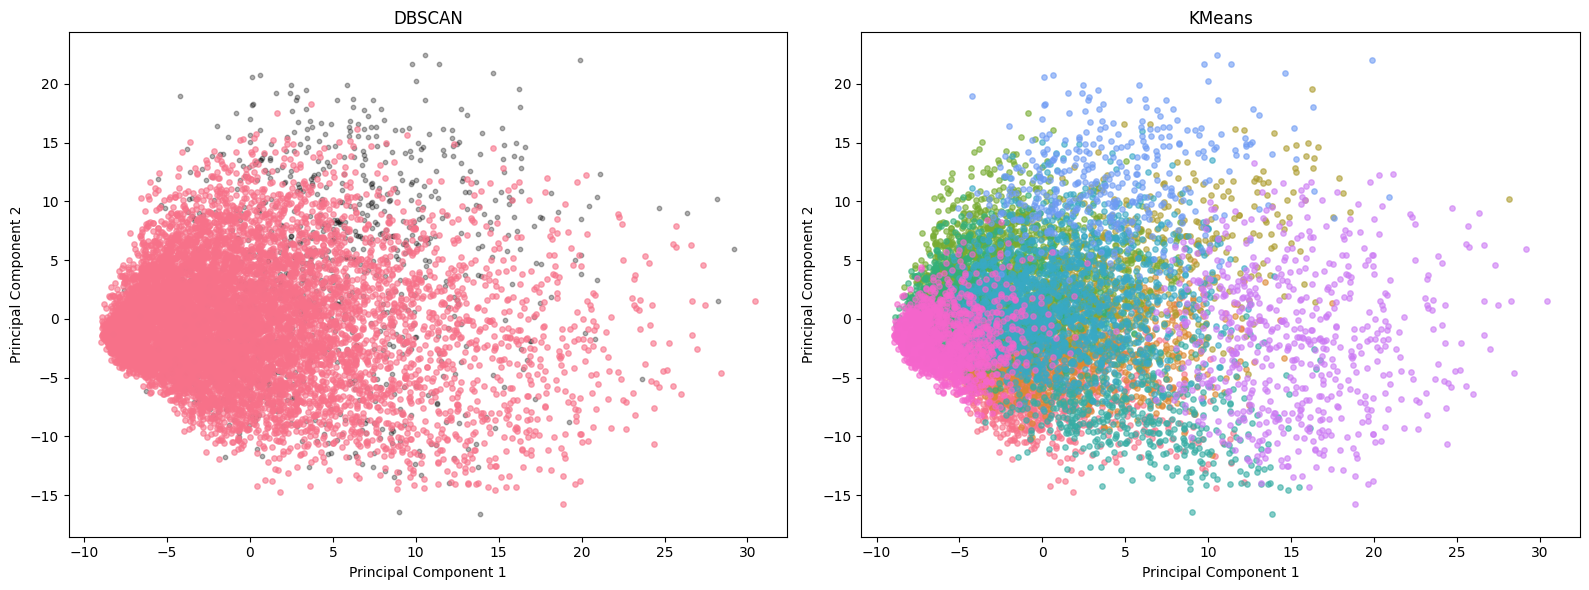

In [15]:
# Compare Models
plot_cluster_comparison(pca_2_features, dbscan_labels, "DBSCAN", kmeans_labels, "KMeans", output_path='../outputs/cluster_comparison.png')

## 4. Evaluation Metrics
Evaluate the clusters using Silhouette score, ARI, and NMI.

In [16]:
dbscan_metrics = evaluate_clusters(pca_50_features, dbscan_labels, true_labels)
kmeans_metrics = evaluate_clusters(pca_50_features, kmeans_labels, true_labels)

print("DBSCAN Metrics:", dbscan_metrics)
print("KMeans Metrics:", kmeans_metrics)

# Save metrics to file
with open('../outputs/metrics.txt', 'w') as f:
    f.write("DBSCAN Metrics:\n")
    f.write(f"  Number of clusters: {dbscan_metrics['n_clusters']}\n")
    f.write(f"  Number of noise points: {dbscan_metrics['n_noise']}\n")
    f.write(f"  Silhouette Score: {dbscan_metrics['silhouette']}\n")
    f.write(f"  ARI: {dbscan_metrics.get('ari', 'N/A')}\n")
    f.write(f"  NMI: {dbscan_metrics.get('nmi', 'N/A')}\n\n")
    f.write("KMeans Metrics:\n")
    f.write(f"  Number of clusters: {kmeans_metrics['n_clusters']}\n")
    f.write(f"  Silhouette Score: {kmeans_metrics['silhouette']}\n")
    f.write(f"  ARI: {kmeans_metrics.get('ari', 'N/A')}\n")
    f.write(f"  NMI: {kmeans_metrics.get('nmi', 'N/A')}\n")

DBSCAN Metrics: {'n_clusters': 1, 'n_noise': 820, 'silhouette': None, 'ari': 0.0018326944332758188, 'nmi': 0.015626015848786087}
KMeans Metrics: {'n_clusters': 10, 'n_noise': 0, 'silhouette': 0.07058647984542635, 'ari': 0.317894075590847, 'nmi': 0.4362979093346334}
